In [1]:
from pathlib import Path

import json
import numpy as np
import pandas as pd

%pip install matplotlib


def find_repo_root():
    path = Path.cwd().resolve()

    for parent in [path, *path.parents]:
        if (parent / "data" / "allstate_claims_data.csv").exists():
            return parent

    raise FileNotFoundError("Could not find data/allstate_claims_data.csv")


REPO_ROOT = find_repo_root()
DATA_PATH = REPO_ROOT / "data" / "allstate_claims_data.csv"

NOTEBOOK_DIR = Path.cwd().resolve()
OUTPUT_DIR = NOTEBOOK_DIR / "eda_outputs"
INVENTORY_PATH = NOTEBOOK_DIR / "cat_inventory.csv"

df = pd.read_csv(DATA_PATH)

print(f"Source: {DATA_PATH.relative_to(REPO_ROOT)}")
print(f"Outputs: {NOTEBOOK_DIR.relative_to(REPO_ROOT)}")

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Applications/Xcode.app/Contents/Developer/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.
Source: data/allstate_claims_data.csv
Outputs: notebooks/ella-zou/Categorical Analysis


In [2]:
cat_cols = [f"cat{i}" for i in range(1, 117)]
n_levels = df[cat_cols].nunique()

cardinality_counts = (
    n_levels.value_counts()
    .sort_index()
    .rename_axis("levels_per_field")
    .reset_index(name="number_of_fields")
)

print("Number of fields by number of distinct levels:")
print(cardinality_counts.to_string(index=False))

print("\nFields with the most distinct levels:")
print(n_levels.sort_values(ascending=False).head(10))

Number of fields by number of distinct levels:
 levels_per_field  number_of_fields
                2                72
                3                 4
                4                12
                5                 3
                7                 4
                8                 3
                9                 1
               11                 1
               13                 1
               15                 1
               16                 2
               17                 2
               19                 2
               20                 2
               23                 1
               51                 1
               61                 1
               84                 1
              131                 1
              326                 1

Fields with the most distinct levels:
cat116    326
cat110    131
cat109     84
cat113     61
cat112     51
cat115     23
cat107     20
cat105     20
cat101     19
cat114     19
dtype: int64


In [3]:
THRESHOLD = 188
# EDA display rule: flag levels with support below 188 rows
# (approximately 0.1% of the dataset).
# Show these levels separately because estimates from smaller groups
# may be less stable. Keep all original rows and levels in the data.

In [4]:
vc = df["cat116"].value_counts()
print(vc.head(5))
print(vc.tail(5))
print(f"There are { (vc < THRESHOLD).sum() } levels that have fewer than 188 rows")

cat116
HK    21061
DJ    20244
CK    10162
DP     9202
GS     8736
Name: count, dtype: int64
cat116
JN    1
BF    1
AD    1
FP    1
AE    1
Name: count, dtype: int64
There are 223 levels that have fewer than 188 rows


In [5]:
rare = vc[vc < THRESHOLD].index
mask = df["cat116"].isin(rare)

print(f"Some rare levels: {list(rare)[:10]}")
print(f"rows in rare levels: {mask.sum():,} ({mask.mean():.2%})")
print(f"median loss, rare levels: {df.loc[mask, 'loss'].median():,.0f}")
print(f"median loss, all rows:    {df['loss'].median():,.0f}")

Some rare levels: ['JX', 'DN', 'FE', 'KI', 'GL', 'FX', 'ED', 'IQ', 'K', 'LD']
rows in rare levels: 6,673 (3.54%)
median loss, rare levels: 2,287
median loss, all rows:    2,116


In [6]:
def level_target_table(field):
    g = df.groupby(field, observed=True)["loss"]
    t = pd.DataFrame({
        "support": g.size(),
        "mean_loss": g.mean(),
        "median_loss": g.median(),
        "q25": g.quantile(0.25),
        "q75": g.quantile(0.75),
    })
    t["iqr"] = t["q75"] - t["q25"]
    return t.sort_values("support", ascending=False)

level_target_table("cat1")

,support,mean_loss,median_loss,q25,q75,iqr
cat1,,,,,,
A,141550,3408.091515,2458.69,1378.375,4407.1100,3028.7350
B,46768,1915.198521,1444.86,916.960,2331.1275,1414.1675


In [7]:
all_tables = []

for field in cat_cols:
    table = level_target_table(field)

    table = table.reset_index().rename(columns={field: "level"})

    table.insert(0, "field", field)

    table["is_rare"] = table["support"] < THRESHOLD

    all_tables.append(table)

all_level_tables = pd.concat(all_tables, ignore_index=True)

OUTPUT_DIR.mkdir(exist_ok=True)

all_level_tables.to_csv(
    OUTPUT_DIR / "categorical_level_target_tables.csv",
    index=False
)

print(f"{all_level_tables['field'].nunique()} level stats")
display(all_level_tables.head(10))

116 level stats


,field,level,support,mean_loss,median_loss,q25,q75,iqr,is_rare
0,cat1,A,141550,3408.091515,2458.69,1378.375,4407.1100,3028.7350,False
1,cat1,B,46768,1915.198521,1444.86,916.960,2331.1275,1414.1675,False
2,cat2,A,106721,2454.139844,1739.25,1042.770,3000.3200,1957.5500,False
3,cat2,B,81597,3800.104171,2833.99,1559.920,4984.6200,3424.7000,False
4,cat3,A,177993,2902.219751,2033.38,1173.080,3652.8000,2479.7200,False
5,cat3,B,10325,5366.640014,4570.91,2675.080,6982.9500,4307.8700,False
6,cat4,A,128395,2826.826831,1974.74,1118.480,3576.3500,2457.8700,False
7,cat4,B,59923,3488.392225,2457.71,1420.680,4481.2550,3060.5750,False
8,cat5,A,123737,2814.648335,1947.07,1106.730,3574.5800,2467.8500,False
9,cat5,B,64581,3464.009806,2464.84,1432.590,4401.9100,2969.3200,False


In [8]:
rows = []
for c in cat_cols:
    vc = df[c].value_counts()
    rows.append({
        "field": c,
        "n_levels": len(vc),
        "top_level": vc.index[0],
        "top_support": vc.iloc[0],
        "top_share": vc.iloc[0] / len(df),
        "min_support": vc.min(),
        "median_support": vc.median(),
        "n_rare_levels": (vc < THRESHOLD).sum(),
        "rare_row_share": vc[vc < THRESHOLD].sum() / len(df),
    })

inventory = pd.DataFrame(rows)
inventory.to_csv(INVENTORY_PATH, index=False)
inventory.sort_values("n_levels", ascending=False).head(10)

,field,n_levels,top_level,top_support,top_share,min_support,median_support,n_rare_levels,rare_row_share
115,cat116,326,HK,21061,0.111837,1,35.0,223,0.035435
109,cat110,131,CL,25305,0.134374,1,29.0,92,0.015484
108,cat109,84,BI,152918,0.812020,1,36.0,71,0.014821
112,cat113,61,BM,26191,0.139079,1,1463.0,20,0.002055
111,cat112,51,E,25148,0.133540,30,1331.0,2,0.000924
114,cat115,23,K,43866,0.232936,1,315.0,9,0.000988
106,cat107,20,F,47310,0.251224,2,1432.0,8,0.002554
104,cat105,20,E,76493,0.406191,1,158.0,11,0.002623
100,cat101,19,A,106721,0.566706,1,2762.0,8,0.001731
113,cat114,19,A,131693,0.699312,1,250.0,8,0.000499


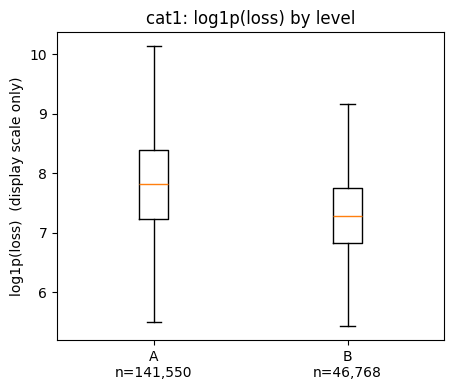

,support,mean_loss,median_loss,q25,q75,iqr
cat1,,,,,,
A,141550,3408.091515,2458.69,1378.375,4407.1100,3028.7350
B,46768,1915.198521,1444.86,916.960,2331.1275,1414.1675


In [9]:
import matplotlib.pyplot as plt

df["log1p_loss"] = np.log1p(df["loss"])

field = "cat1"
levels = df[field].value_counts().index
data = [df.loc[df[field] == lv, "log1p_loss"] for lv in levels]

plt.figure(figsize=(5, 4))
plt.boxplot(data, tick_labels=[f"{lv}\nn={len(d):,}" for lv, d in zip(levels, data)],
            showfliers=False)
plt.ylabel("log1p(loss)  (display scale only)")
plt.title(f"{field}: log1p(loss) by level")
plt.show()

level_target_table(field)

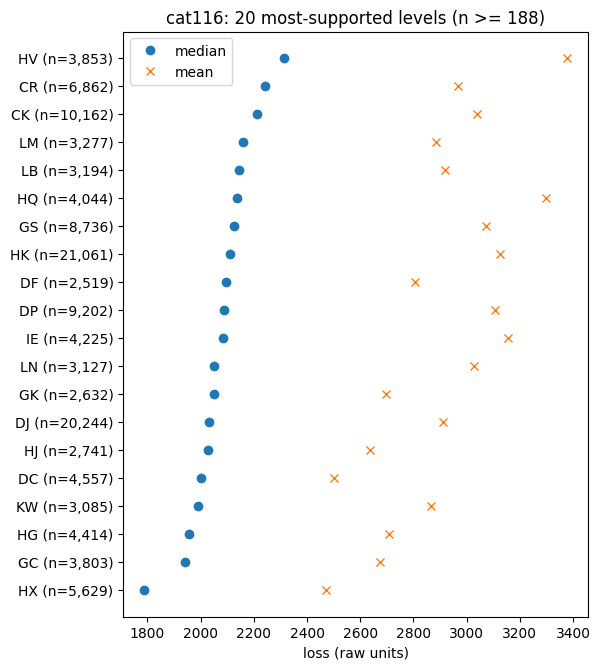

rare levels: 223, rows: 6,673 (3.54%), mean: 3,652, median: 2,287


In [10]:
field = "cat116"
t = level_target_table(field)
big = (
    t[t["support"] >= THRESHOLD]
    .nlargest(20, "support")
    .sort_values("median_loss")
)

plt.figure(figsize=(6, 0.28 * len(big) + 2))
plt.plot(big["median_loss"], range(len(big)), "o", label="median")
plt.plot(big["mean_loss"], range(len(big)), "x", label="mean")
plt.yticks(range(len(big)), [f"{lv} (n={int(n):,})" for lv, n in zip(big.index, big["support"])])
plt.xlabel("loss (raw units)")
plt.title(f"{field}: 20 most-supported levels (n >= {THRESHOLD})")
plt.legend()
plt.show()

rare = t.index[t["support"] < THRESHOLD]
mask = df[field].isin(rare)
print(f"rare levels: {len(rare)}, rows: {mask.sum():,} ({mask.mean():.2%}), "
      f"mean: {df.loc[mask, 'loss'].mean():,.0f}, median: {df.loc[mask, 'loss'].median():,.0f}")